In [1]:
!pip install torch torcheeg python-picard autoreject

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.4/251.4 kB 5.2 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.5/231.5 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of mne to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mne[hdf5] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pymatreader to determine which version is compatible with other requirements. 

In [2]:
import mne
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch 
import torcheeg
from torcheeg import datasets
from torcheeg import transforms
from torch.utils.data import Dataset

In [3]:
emotion_mapping = {
    (0, 0): "Boring",  # Low arousal, Low valence
    (0, 1): "Calm",    # Low arousal, High valence
    
    (1, 0): "Horror",  # High arousal, Low valence    
    (1, 1): "Funny"    # High arousal, High valence
}

In [4]:
def fastica_symmetric(X, n_components=None, tol=1e-5, max_iter=200, function='logcosh', alpha=1.0):
    """
    Perform Independent Component Analysis (ICA) using the symmetric FastICA algorithm.

    This function implements a symmetric version of the FastICA algorithm based on
    a fixed-point iteration scheme. The algorithm first centers and whitens the input
    data, and then iteratively estimates the independent components using a chosen
    nonlinearity.

    Parameters:
        X (torch.Tensor): Input data tensor with shape (n_samples, n_features). Each
            row corresponds to a sample, and each column corresponds to an observed mixed signal.
        n_components (int, optional): Number of independent components to extract.
            Defaults to None, in which case it is set to the number of features in X.
        tol (float, optional): Tolerance for the convergence criterion. The algorithm
            stops when the maximum absolute change in the weight vectors (in terms of
            their dot-product convergence) falls below this threshold. Default is 1e-5.
        max_iter (int, optional): Maximum number of iterations allowed for the fixed-point
            update process. Defaults to 200.
        function (str, optional): Nonlinearity used in the fixed-point iteration.
            Supported options are 'logcosh' and 'exp'. The 'logcosh' function uses
            a hyperbolic tangent nonlinearity with scaling by alpha, while 'exp'
            applies an exponential damping function. Default is 'logcosh'.
        alpha (float, optional): Parameter for scaling the nonlinearity in the 'logcosh'
            function. Defaults to 1.0.

    Returns:
        S (torch.Tensor): Estimated source signals (independent components) of shape
            (n_samples, n_components). This is computed using the unmixing matrix applied
            to the centered data.
        mixing (torch.Tensor): Estimated mixing matrix of shape (n_features, n_components).
            This is computed as the pseudo-inverse of the unmixing matrix.
        unmixing (torch.Tensor): Estimated unmixing matrix of shape (n_components, n_features)
            such that when applied to the centered data, the independent components are obtained.

    Notes:
        - The input data is centered and whitened prior to the estimation of independent
          components. Whitening is performed using eigenvalue decomposition of the covariance
          matrix.
        - The algorithm initializes the weight matrix with random orthogonal vectors.
        - The fixed-point iteration involves projecting the whitened data onto the weight vectors,
          applying the nonlinearity elementwise, and then updating the weights.
        - A symmetric decorrelation step is performed at each iteration to ensure that all estimated
          components remain orthogonal.
        - Convergence is evaluated by comparing the dot products between the updated and previous
          weight vectors.
        - In the current implementation, the 'exp' nonlinearity branch appears twice and performs the
          same operation; ensure that the correct nonlinearity is chosen by the user.
        - A ValueError is raised if the provided nonlinearity is not supported.

    Example:
        >>> import torch
        >>> # Generate some synthetic data (n_samples=1000, n_features=5)
        >>> X = torch.randn(1000, 5)
        >>> # Run FastICA to extract 5 independent components
        >>> S, mixing, unmixing = fastica_symmetric(X, n_components=5)
        >>> print(S.shape)  # Should print: torch.Size([1000, 5])
    
    See Also:
        torch.linalg.eigh: For eigenvalue decomposition.
        torch.linalg.qr: For QR factorization used in initializing orthogonal weights.
    
    """
    device = 'cuda'
    X = X.to('cuda')
    X = X.float()
    n_samples, n_features = X.shape
    if n_components is None:
        n_components = n_features

    # Center and whiten
    X_centered = X - X.mean(0, keepdim=True)
    cov = (X_centered.T @ X_centered) / n_samples
    eigvals, eigvecs = torch.linalg.eigh(cov)
    idx = torch.argsort(eigvals, descending=True)
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    whitening_matrix = eigvecs[:, :n_components] @ torch.diag(1.0 / torch.sqrt(eigvals[:n_components].clamp(min=1e-10)))
    X_white = X_centered @ whitening_matrix

    # Initialize all weights (orthogonal)
    W = torch.randn(n_components, n_components, device=device)
    W = torch.linalg.qr(W.T).Q.T

    # Define nonlinearity
    def g(u):
        if function == 'logcosh':
            return torch.tanh(alpha * u)
        elif function == 'exp':
            return u * torch.exp(-0.5 * u**2)
        elif function == 'exp':
            return (1 - u**2) * torch.exp(-0.5 * u**2)
        else:
            raise ValueError("Unsupported function. Use 'logcosh' or 'exp'.")

    def g_prime(u):
        if function == 'logcosh':
            return alpha * (1 - torch.tanh(alpha * u) ** 2)
        elif function == 'exp':
            return (1 - u**2) * torch.exp(-0.5 * u**2)
        elif function == 'exp':
            return (1 - u**2) * torch.exp(-0.5 * u**2)
        else:
            raise ValueError("Unsupported function. Use 'logcosh' or 'exp'.")
    
    with torch.no_grad():
        for _ in range(max_iter):
            W_old = W.clone()
        
            # Initialize accumulators for batched statistics
            batch_size = 10000   # tune depending on GPU memory
            W_new_accum = torch.zeros_like(W)
            Gp_mean_accum = torch.zeros(W.shape[0], device=device)
        
            # --- Process data in mini-batches ---
            for i in range(0, n_samples, batch_size):
                Xb = X_white[i:i+batch_size]                  # (batch, n_components)
                WXb = Xb @ W.T                                # projection
                GWXb = g(WXb)                                 # nonlinearity
                Gpb = g_prime(WXb)                            # derivative
        
                # Accumulate results
                W_new_accum += Xb.T @ GWXb
                Gp_mean_accum += Gpb.sum(0)
        
                # Free intermediate tensors to save GPU memory
                del Xb, WXb, GWXb, Gpb
                torch.cuda.empty_cache()
        
            # --- Combine accumulated results ---
            W_new = (W_new_accum / n_samples) - (Gp_mean_accum / n_samples * W.T)
            W_new = W_new.T
        
            # --- Symmetric decorrelation (orthogonalize all at once)
            s, u = torch.linalg.eigh(W_new @ W_new.T)
            W = (u @ torch.diag(s.pow(-0.5)) @ u.T) @ W_new
        
            # --- Convergence check ---
            lim = torch.max(torch.abs(torch.abs((W * W_old).sum(dim=1)) - 1.0))
            if lim < tol:
                break

    # Compute sources
    unmixing = W @ whitening_matrix.T
    mixing = torch.linalg.pinv(unmixing)
    S = X_centered @ unmixing.T
    return S, mixing, unmixing

In [5]:
def max_eeg_readings(df, max_readings):
    if isinstance(data, (pd.DataFrame, pd.Series)):
        arr = data.to_numpy()
    elif isinstance(data, np.ndarray):
        arr = data
    else:
        raise TypeError("Input must be a pandas DataFrame, Series, or numpy ndarray.")
    arr = arr[~np.isnan(arr)]
    arr = arr.reshape(-1)
    arr = np.sort(arr)
    arr = arr[::-1]
    return arr[:max_readings]

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_eeg_numpy(eeg_data, sfreq, ch_names=None, start=0, duration=10, title="EEG Channels"):
    """
    Plot EEG channels from a NumPy array.

    Parameters
    ----------
    eeg_data : np.ndarray
        2D array of shape (n_channels, n_samples)
    sfreq : float
        Sampling frequency in Hz
    ch_names : list of str
        Optional list of channel names
    start : float
        Start time (in seconds)
    duration : float
        Duration (in seconds)
    """
    n_channels, n_samples = eeg_data.shape
    start_idx = int(start * sfreq)
    end_idx = int((start + duration) * sfreq)
    time = np.arange(start_idx, end_idx) / sfreq

    plt.figure(figsize=(12, 8))
    offset = 0
    for i in range(n_channels):
        plt.plot(time, eeg_data[i, start_idx:end_idx] + offset, label=ch_names[i] if ch_names else f"Ch {i+1}")
        offset += np.ptp(eeg_data[i, start_idx:end_idx]) * 1.5  # spacing between channels

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV, relative offset)")
    plt.title(title)
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout()
    plt.show()

In [7]:
def plot_sample(df, max_readings, duration, title):
    print(max_eeg_readings(df, max_readings))
    channels = list(df.columns)[:-1]
    plot_eeg_numpy(df[channels].to_numpy().T, 128, channels, 0, duration, title=title)   
    

In [8]:
def plot_all_subject_data(df_boring, df_calm, df_horror, df_funny, duration):
    max_readings = 12
    plot_sample(df_boring, max_readings, duration, "Boring Game Sample")
    plot_sample(df_calm, max_readings, duration, "Calm Game Sample")
    plot_sample(df_horror, max_readings, duration, "Horror Game Sample")
    plot_sample(df_funny, max_readings, duration, "Funny Game Sample")

In [ ]:
def preprocessing_pieline(
    arr, epoch_length_in_secs,
    epoch_overlap_in_secs,
    band_pass_lower_bound_freq=1.0,
    band_pass_upper_bound_freq=40.0
):
    
    from mne.preprocessing import ICA
    
    raw_filtered = raw.copy().filter(l_freq=band_pass_lower_bound_freq, h_freq=band_pass_upper_bound_freq)
    ica = ICA(n_components=0.99, method='picard', max_iter=800, random_state=42)
    ica.fit(raw_filtered)
    ica_data = ica.apply(raw)
    epochs = mne.make_fixed_length_epochs(
        ica_data, duration=epoch_length_in_secs, overlap=epoch_overlap_in_secs, preload=True
    )
    ar = AutoReject(random_state=42, n_jobs=-1)
    ar.fit(epochs)

    # Apply Autoreject cleaning
    epochs_clean = ar.transform(epochs)


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_artifact_correlations(raw, channels, artifact_windows, baseline_window=(10, 15)):
    """
    Plot channel correlation matrices for artifact and baseline time windows.

    This function extracts EEG (or MEG) data from specified time windows, computes 
    channel-wise Pearson correlation matrices, and visualizes them as heatmaps.
    It can be used to compare suspected artifact periods with a clean baseline 
    segment to identify abnormal channel coupling patterns.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the continuous EEG/MEG data.
    channels : list of str
        List of channel names corresponding to the data used for plotting.
        Typically `raw.ch_names` or a subset of it.
    artifact_windows : list of tuple
        List of time windows (start, stop) in seconds that mark suspected 
        artifact periods.
    baseline_window : tuple of float, optional
        A single time window (start, stop) in seconds representing a clean 
        baseline period for comparison. Default is (10, 15).

    Notes
    -----
    - The function assumes that data from all channels in `channels` are included
      in the Raw object and aligned in order.
    - Correlation matrices are plotted for each artifact window and one for the
      baseline window.
    """

    # Loop through each artifact window and compute correlation matrices
    for start, stop in artifact_windows:
        # Extract data and corresponding time points
        data, times = raw.get_data(start=start, stop=stop, return_times=True)

        # Compute Pearson correlation coefficients between channels
        corr_matrix = np.corrcoef(data)
        
        # --- Visualization ---
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
        ax.set_title(f'Channel correlation ({start:.1f}–{stop:.1f}s)')
        ax.set_xticks(range(len(channels)))
        ax.set_xticklabels(channels, rotation=90)
        ax.set_yticks(range(len(channels)))
        ax.set_yticklabels(channels)
        plt.colorbar(im, ax=ax, label='Correlation coefficient')
        plt.tight_layout()
        plt.show()

    # --- Baseline comparison ---
    # Extract baseline data and compute its correlation matrix
    data_base, _ = raw.get_data(start=baseline_window[0],
                                stop=baseline_window[1],
                                return_times=True)
    corr_baseline = np.corrcoef(data_base)

    # Plot baseline correlation matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(corr_baseline, vmin=-1, vmax=1, cmap='RdBu_r')
    plt.title(f'Baseline correlation ({baseline_window[0]}–{baseline_window[1]}s)')
    plt.xticks(range(len(channels)), channels, rotation=90)
    plt.yticks(range(len(channels)), channels)
    plt.colorbar(label='Correlation coefficient')
    plt.tight_layout()
    plt.show()

In [9]:
from sklearn.decomposition import FastICA

path = r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G1AllChannels.csv'

df = pd.read_csv(path)

channels = list(df.columns)[:-1]

info = mne.create_info(ch_names=channels, sfreq=128, ch_types='eeg')
raw = mne.io.RawArray(df[channels].to_numpy().T, info)

In [10]:
from mne.time_frequency import Spectrum

spect = raw.compute_psd()
print(spect.shape)

raw_filtered = raw.copy()
raw_filtered.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

spect_filtered = raw_filtered.compute_psd()
print(spect_filtered.shape)

(14, 1025)
(14, 1025)


In [11]:
from mne.preprocessing import ICA

ica = ICA(n_components=0.99, method='picard', max_iter=800, random_state=42)

ica.fit(raw_filtered)

Method,picard
Fit parameters,max_iter=800
Fit,35 iterations on raw data (38252 samples)
ICA components,14
Available PCA components,14
Channel types,eeg
ICA components marked for exclusion,—


In [12]:
raw_filtered_low = raw_filtered.copy().filter(l_freq=0.1, h_freq=None)
ica_data = ica.apply(raw_filtered_low)

In [13]:
data_array, times_array = ica_data[:]
print(f"Shape of extracted data: {data_array.shape}")
print(f"Shape of extracted times: {times_array.shape}")

Shape of extracted data: (14, 38252)
Shape of extracted times: (38252,)


In [14]:
data_array=np.array(data_array)

In [15]:
data_array_centered = data_array - data_array.mean(axis=0, keepdims=True)

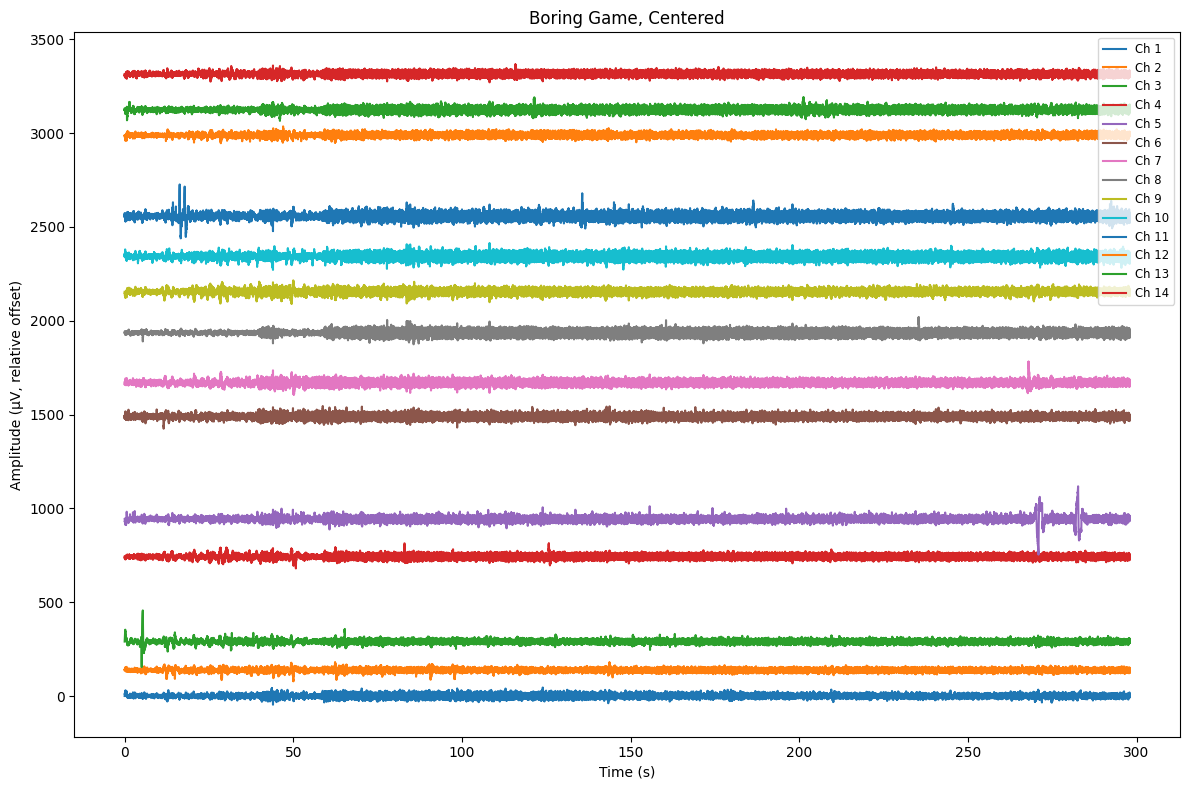

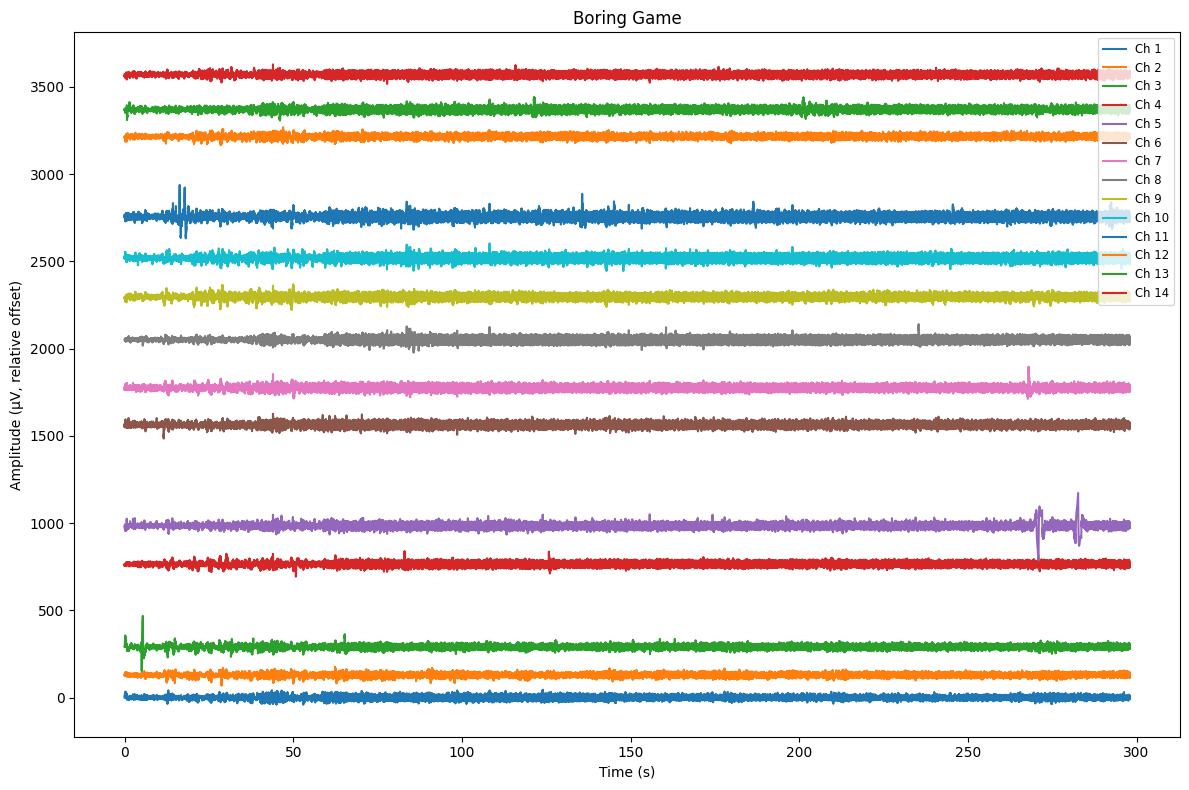

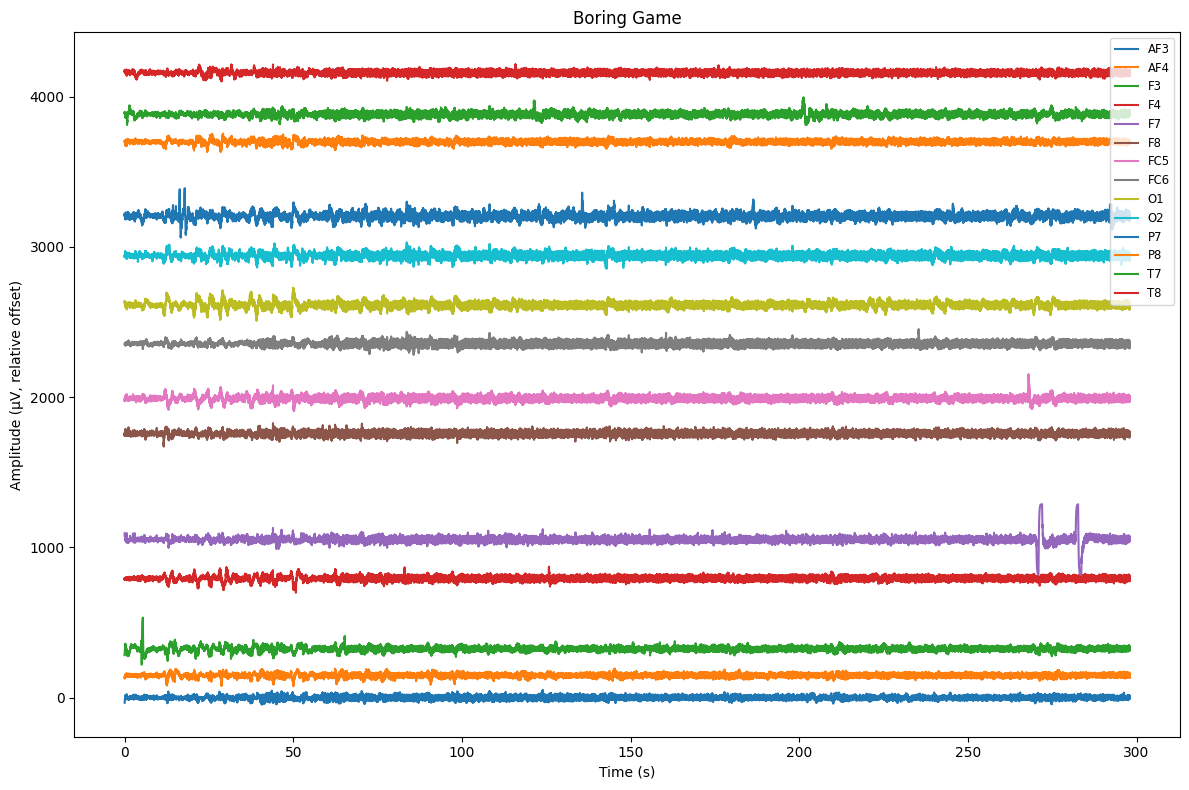

In [18]:
# print(max_eeg_readings(data_array, 12))
duration=298
start=0
plot_eeg_numpy(data_array_centered, 128, duration=duration, start=start, title="Boring Game, Centered")
plot_eeg_numpy(data_array, 128, duration=duration, start=start, title="Boring Game")
channels = list(df.columns)[:-1]
plot_eeg_numpy(df[channels].to_numpy().T, 128, channels, start=start, duration=duration, title="Boring Game")



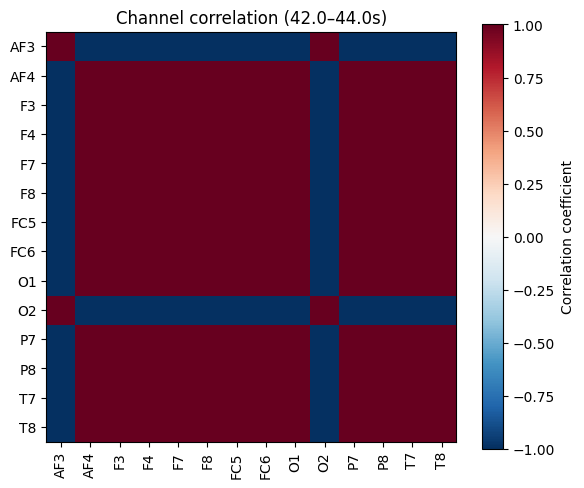

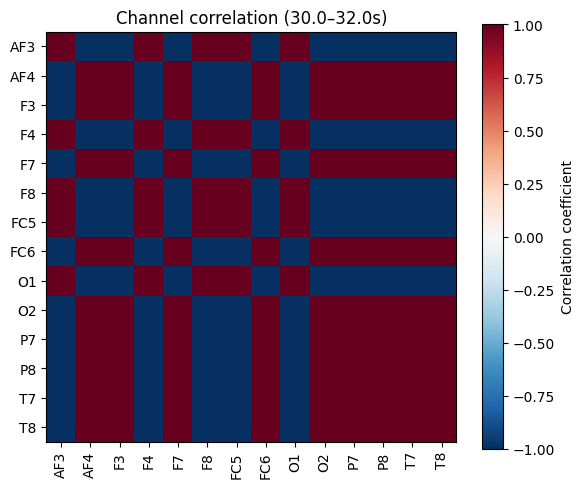

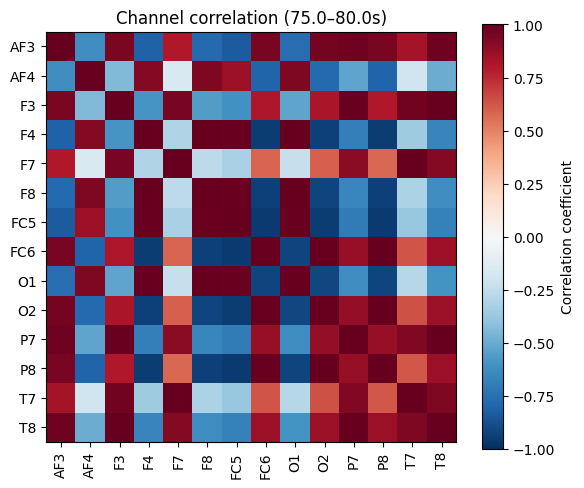

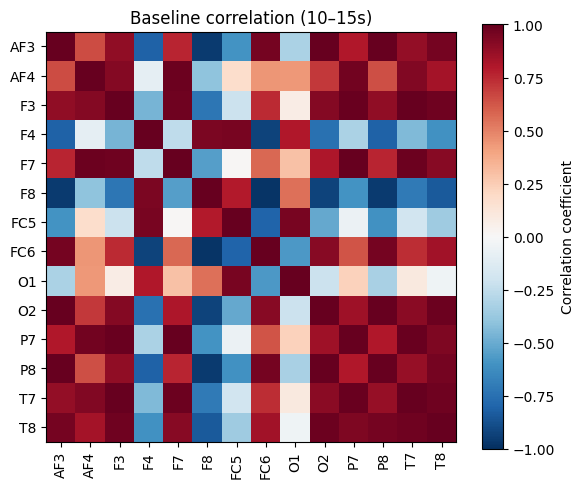

In [29]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define the suspected artifact periods (in seconds)
# -------------------------------
# Example: three red-circled regions in your image
artifact_windows = [(42, 44), (30, 32), (75, 80)]  # replace with your actual times

# -------------------------------
# 2. Band-pass filter (optional)
# -------------------------------
# Filtering helps remove DC drift for better correlation computation
raw_filt = ica_data.copy().filter(l_freq=1., h_freq=40., fir_design='firwin')

# -------------------------------
# 3. Extract data and compute correlation matrices for each artifact window
# -------------------------------
for start, stop in artifact_windows:
    data, times = raw_filt.get_data(start=start, stop=stop, return_times=True)
    corr_matrix = np.corrcoef(data)
    
    # -------------------------------
    # 4. Visualize the correlation matrix
    # -------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_title(f'Channel correlation ({start:.1f}–{stop:.1f}s)')
    ax.set_xticks(range(len(raw.ch_names)))
    ax.set_xticklabels(raw.ch_names, rotation=90)
    ax.set_yticks(range(len(raw.ch_names)))
    ax.set_yticklabels(raw.ch_names)
    plt.colorbar(im, ax=ax, label='Correlation coefficient')
    plt.tight_layout()
    plt.show()

# -------------------------------
# 5. Compare with baseline (non-artifact) periods
# -------------------------------
baseline_window = (10, 15)  # choose a clean region
data_base, _ = raw_filt.get_data(start=baseline_window[0],
                                 stop=baseline_window[1],
                                 return_times=True)
corr_baseline = np.corrcoef(data_base)

plt.figure(figsize=(6, 5))
plt.imshow(corr_baseline, vmin=-1, vmax=1, cmap='RdBu_r')
plt.title(f'Baseline correlation ({baseline_window[0]}–{baseline_window[1]}s)')
plt.xticks(range(len(raw.ch_names)), raw.ch_names, rotation=90)
plt.yticks(range(len(raw.ch_names)), raw.ch_names)
plt.colorbar(label='Correlation coefficient')
plt.tight_layout()
plt.show()


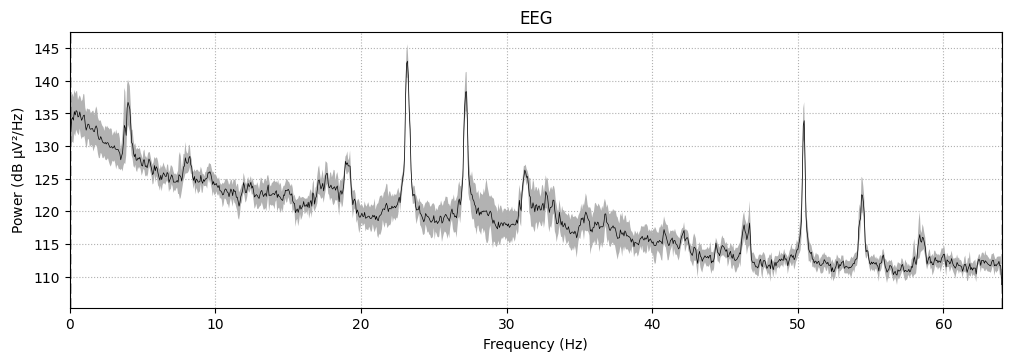

In [30]:
_=spect.plot(
    average=True, amplitude=False
)

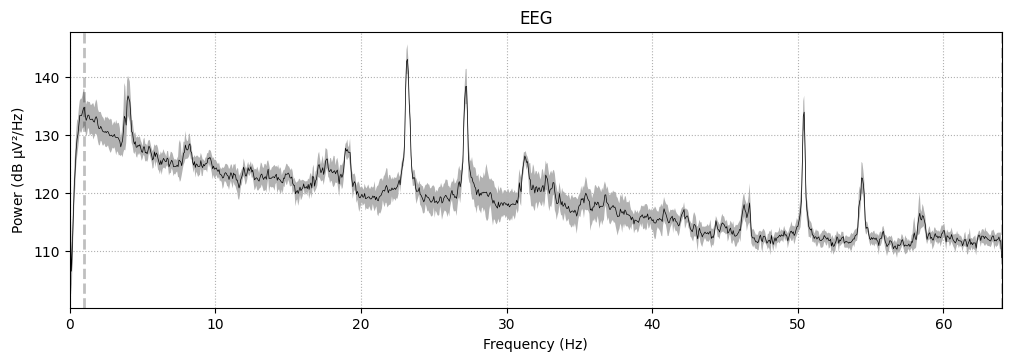

In [31]:
# raw_filtered_low_and_line = raw.notch_filter(freqs=[50, 100, 150], method='spectrum_fit')

spectrum = ica_data.compute_psd()
_=spectrum.plot(
    average=True, amplitude=False
)

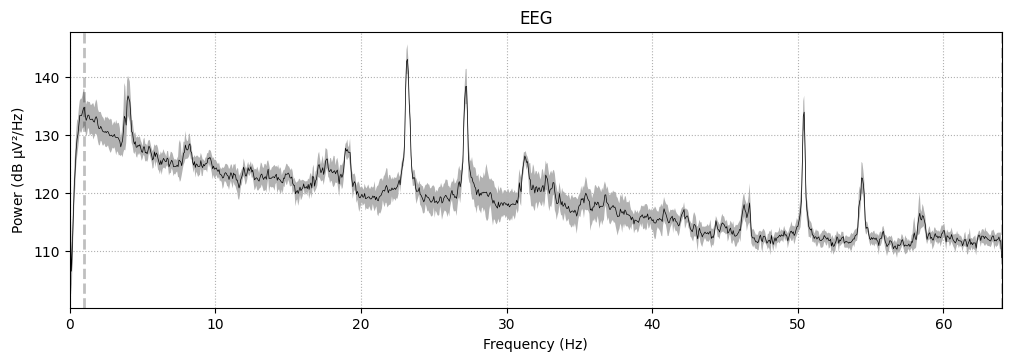

In [35]:
ica_data_centered = ica_data.copy()
data = ica_data.get_data()
data_centered = data - data.mean(axis=1, keepdims=True)
ica_data_centered._data = data_centered

spectrum_centered = ica_data_centered.compute_psd()
_=spectrum_centered.plot(
    average=True, amplitude=False
)

[162.432  157.7999 153.231  152.8723 149.7182 149.1655 148.9428 147.6301
 144.2747 143.4498 142.2013 142.0533]


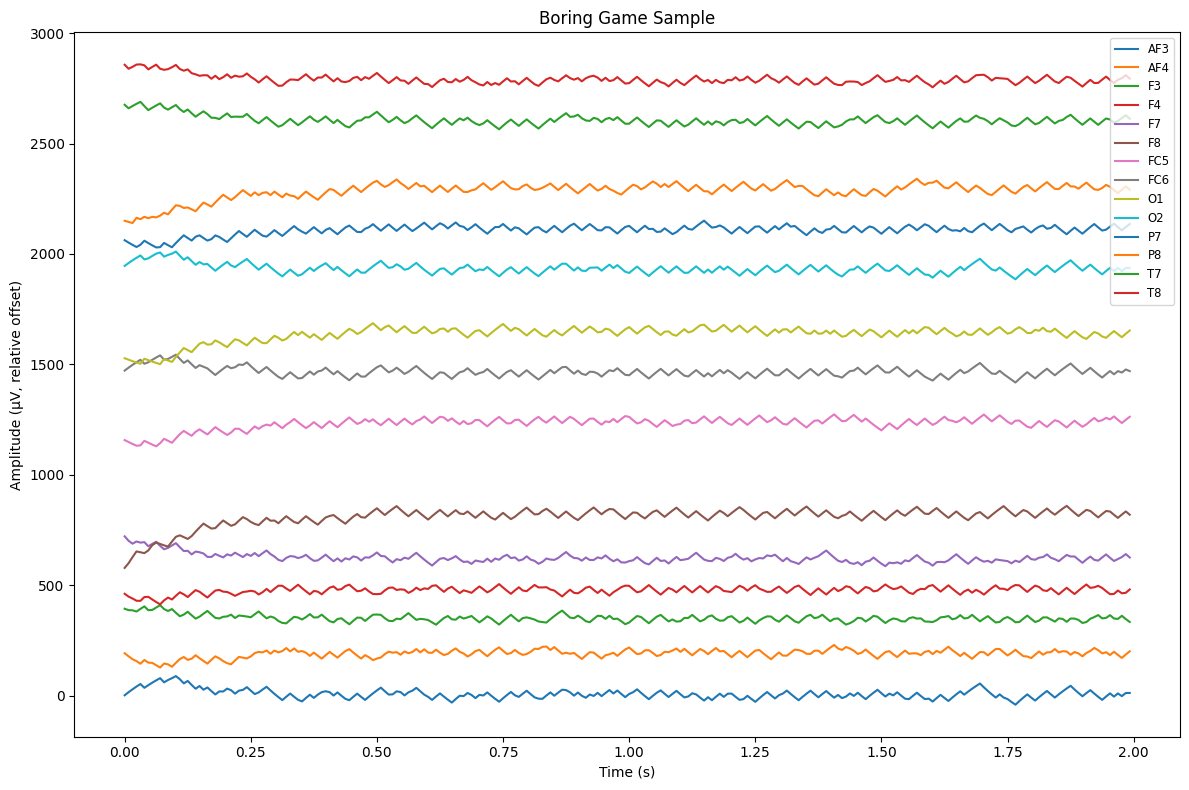

[182.3034 179.8053 178.9397 175.3614 172.0925 171.5547 169.428  168.7181
 165.2425 160.7899 157.2652 156.0531]


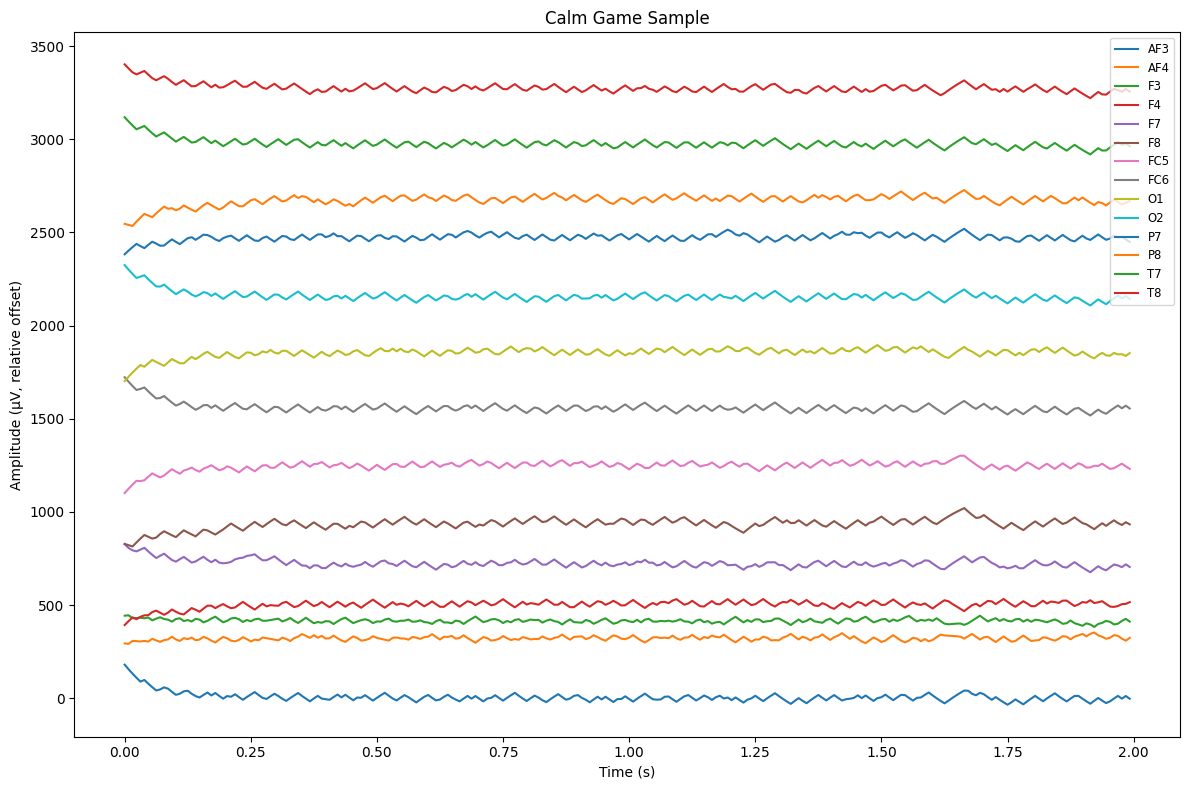

[214.0299 212.6914 211.2674 209.7526 208.141  206.4266 205.4587 204.6828
 204.6028 203.5731 202.6625 201.5671]


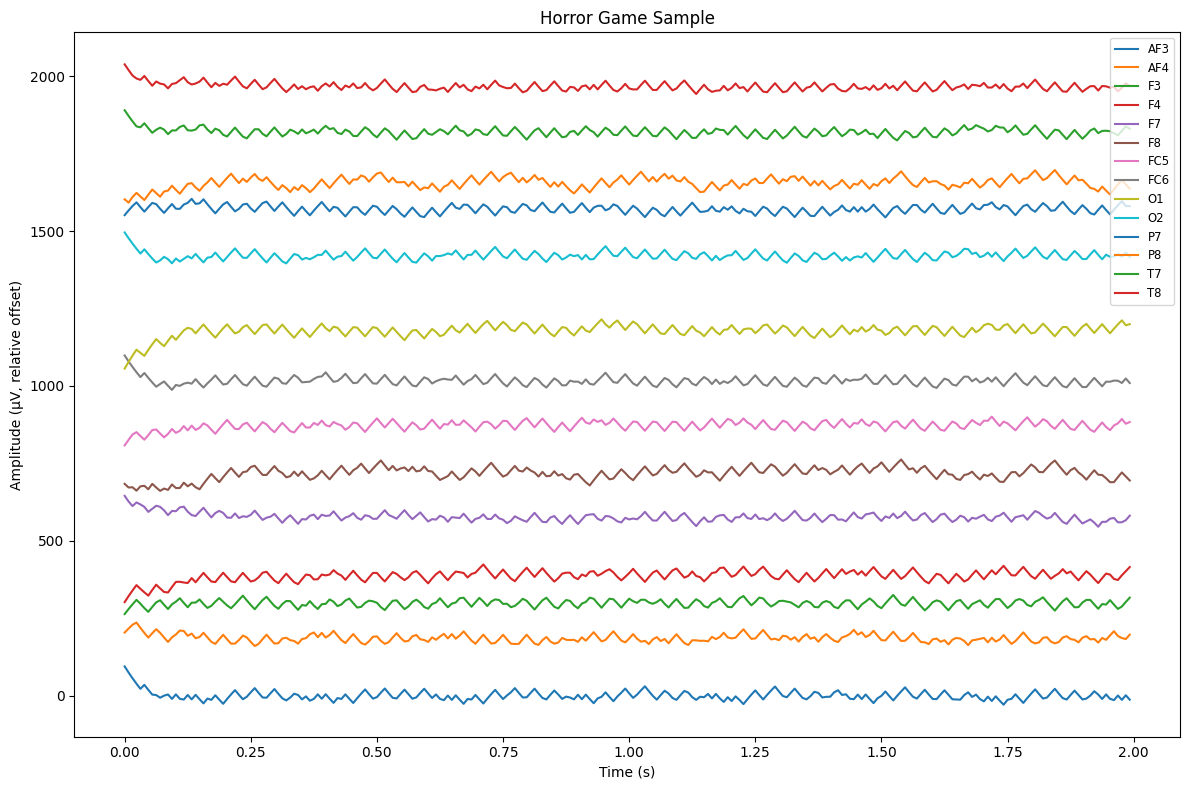

[223.5467 222.8156 222.0379 221.2105 220.8895 220.3303 219.9889 219.3939
 219.0307 218.3978 218.0114 217.3381]


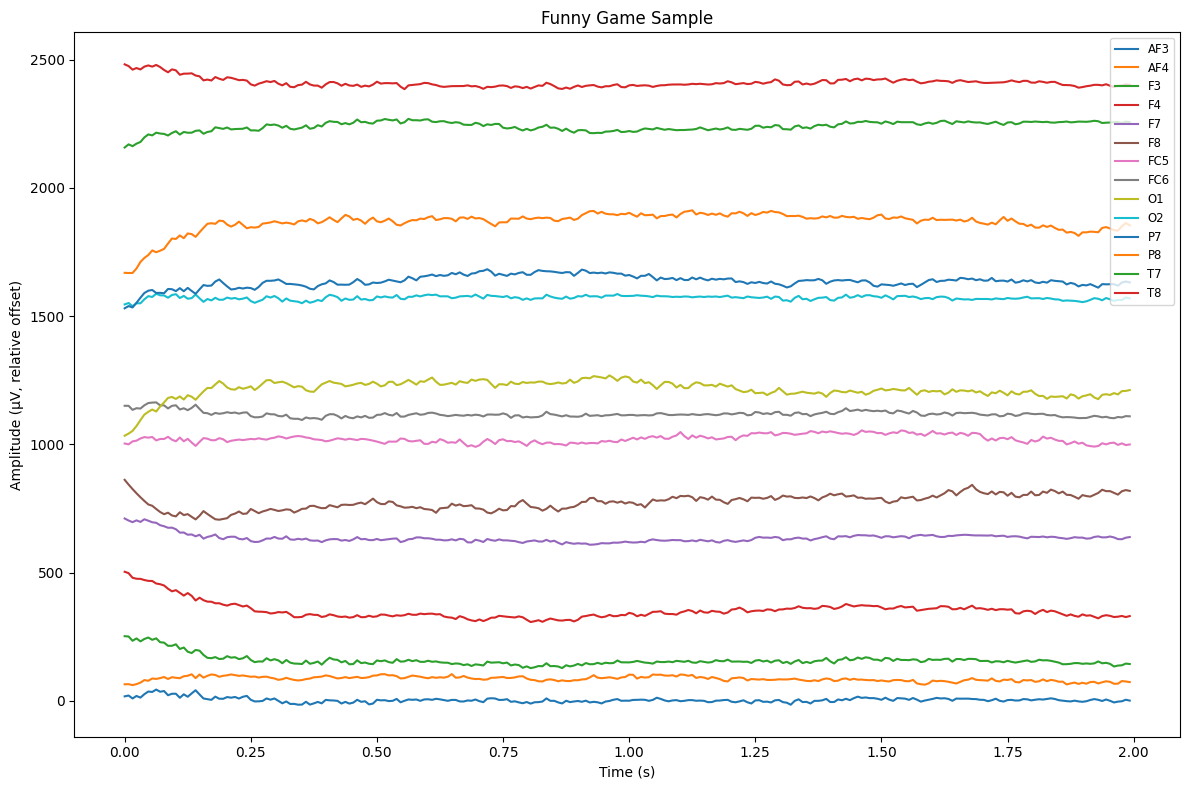

In [62]:
plot_all_subject_data(
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G1AllChannels.csv'),
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G2AllChannels.csv'),
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G3AllChannels.csv'),
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G4AllChannels.csv'),
    duration=2
)

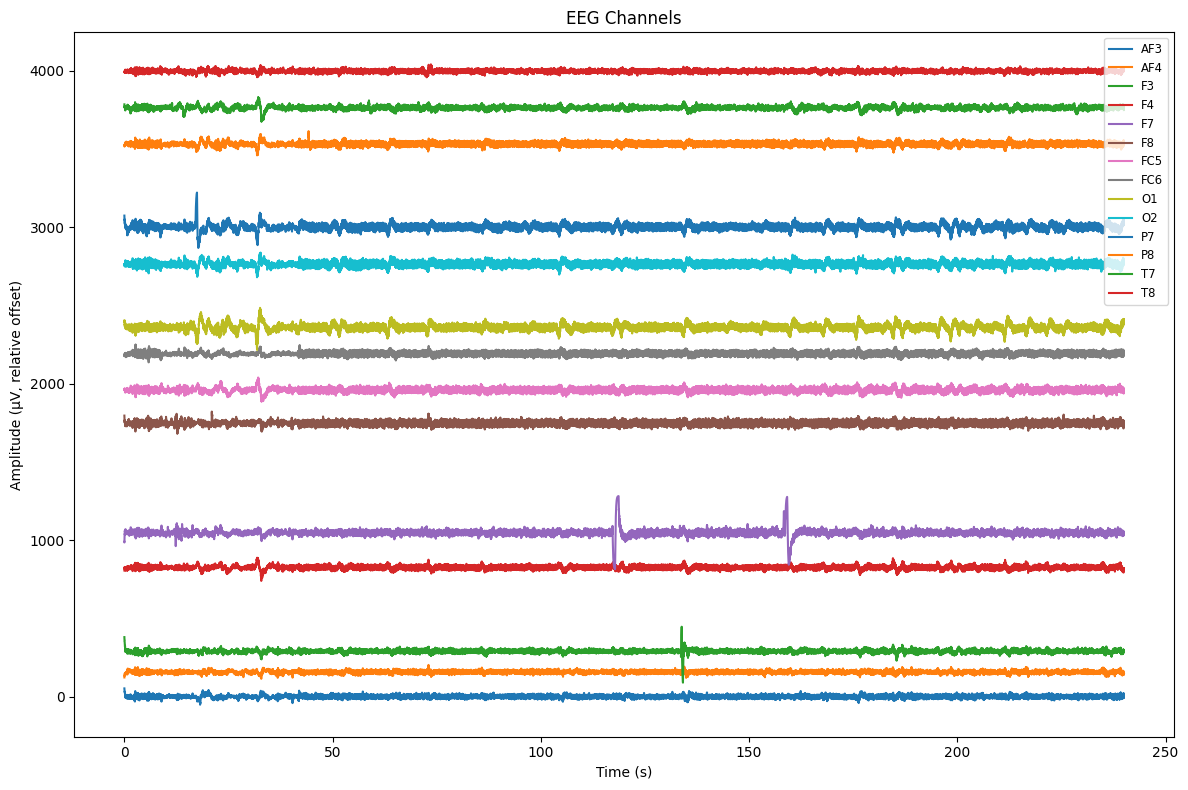

In [21]:
plot_eeg_numpy(df_preprocessed[channels].to_numpy().T, sfreq=128, ch_names=channels, duration=60*4, "sample 1 boring")

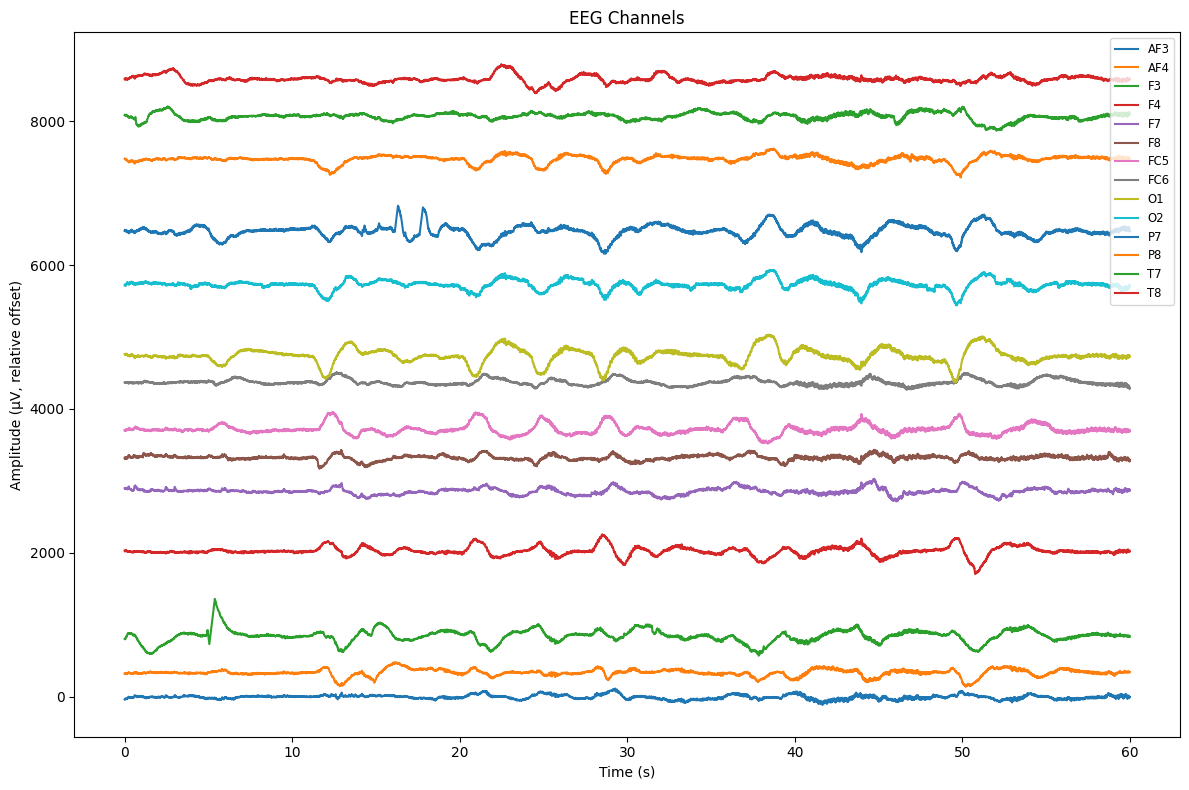

In [41]:
plot_eeg_numpy(df_raw[channels].to_numpy().T, sfreq=128, ch_names=channels, duration=60)

In [102]:
power_FFT = (torch.abs(rfft(tensor[0].unsqueeze(0), axis=0)) ** 2) / (tensor.shape[0] * 128)
freqs = torch.fft.rfftfreq(tensor.shape[0], 1 / 128)

spectrogram = torch.tensor(power_FFT)
spectrogram

/tmp/ipykernel_37/837133780.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spectrogram = torch.tensor(power_FFT)


tensor([[5.6386e-04, 2.3255e-04, 1.6953e-03, 7.5936e-05, 6.8342e-04, 4.7459e-04,
         7.5950e-07, 2.5105e-05, 3.6753e-04, 7.5950e-07, 1.1255e-03, 8.0207e-06,
         1.0042e-04, 4.7459e-06]])

# Data Reshaping Steps
* Assign labels to data properly.
* Divide data based on given sample rate = 128, with an overlap precentage.
* Save last 15% of the data in each file as val and test.
* Concate samples to build train, validation, and test sets.

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label